## **Read data and Imports**

In [1]:
# =========================================================
# 0) GPU + REPRODUCIBILITY SETUP
# =========================================================

import os
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 0) GPU SETUP - RUN THIS FIRST AFTER RESTART RUNTIME
# =========================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
        )
        logical_gpus = tf.config.list_logical_devices("GPU")
        print("Physical GPUs:", gpus)
        print("Logical GPUs:", logical_gpus)
        print("GPU memory limit set to 3000 MB")
    except RuntimeError as e:
        print("GPU was already initialized. Restart runtime and run this cell first.")
        print(e)
else:
    print("No GPU found. Go to Runtime > Change runtime type > GPU")

2026-05-12 21:23:15.075993: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 21:23:15.076070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 21:23:15.077543: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 21:23:15.085881: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 21:23:15.922527: W tensorflow/compiler/tf2

Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPU memory limit set to 3000 MB


2026-05-12 21:23:16.701016: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 21:23:16.769442: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 21:23:16.769501: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 21:23:16.770956: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 21:23:16.771014: I external/local_xla/xla/stream_executor

In [2]:
# =========================================================
# 1) PATHS + CONFIGURATION
# =========================================================

TRAIN_CSV = "../../../Data/dataset_split/train/train.csv"
VAL_CSV   = "../../../Data/dataset_split/val/val.csv"
TEST_CSV  = "../../../Data/dataset_split/test/test.csv"

TRAIN_IMAGE_DIR = "../../../Data/dataset_split/train/images_processed"
VAL_IMAGE_DIR   = "../../../Data/dataset_split/val/images_processed"
TEST_IMAGE_DIR  = "../../../Data/dataset_split/test/images_processed"

# Choose one: "binary", "3class", "5class"
# Recommended for your current dataset: "3class"
TARGET_MODE = "3class"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EMB_BATCH_SIZE = 16

# Use milder oversampling than before.
# For 5-class, the notebook automatically lowers this to avoid repeating class 3 too much.
MINORITY_TARGET_COUNT_3CLASS = 800
MINORITY_TARGET_COUNT_5CLASS = 300
MINORITY_TARGET_COUNT_BINARY = 1200

K_NEIGHBORS = 5
PCA_COMPONENTS_FOR_GRAPH = 64

# These features can improve accuracy, but some are ophthalmic annotations.
# For a very strict no-leakage experiment, set USE_OPHTHALMIC_METADATA=False.
USE_OPHTHALMIC_METADATA = True

safe_features = [
    "patient_age",
    "patient_sex",
    "diabetes"
]

ophthalmic_metadata_features = [
    "optic_disc",
    "vessels",
    "macula",
    "macular_edema",
    "drusens",
    "myopic_fundus"
]

tabular_features = safe_features + ophthalmic_metadata_features if USE_OPHTHALMIC_METADATA else safe_features

print("TARGET_MODE:", TARGET_MODE)
print("Tabular features:", tabular_features)
print("Train CSV exists:", os.path.exists(TRAIN_CSV), TRAIN_CSV)
print("Val CSV exists  :", os.path.exists(VAL_CSV), VAL_CSV)
print("Test CSV exists :", os.path.exists(TEST_CSV), TEST_CSV)
print("Train image dir exists:", os.path.exists(TRAIN_IMAGE_DIR), TRAIN_IMAGE_DIR)
print("Val image dir exists  :", os.path.exists(VAL_IMAGE_DIR), VAL_IMAGE_DIR)
print("Test image dir exists :", os.path.exists(TEST_IMAGE_DIR), TEST_IMAGE_DIR)

TARGET_MODE: 3class
Tabular features: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus']
Train CSV exists: True ../../../Data/dataset_split/train/train.csv
Val CSV exists  : True ../../../Data/dataset_split/val/val.csv
Test CSV exists : True ../../../Data/dataset_split/test/test.csv
Train image dir exists: True ../../../Data/dataset_split/train/images_processed
Val image dir exists  : True ../../../Data/dataset_split/val/images_processed
Test image dir exists : True ../../../Data/dataset_split/test/images_processed


In [3]:
# =========================================================
# 2) LOAD DATA
# =========================================================

train_data = pd.read_csv(TRAIN_CSV)
val_data   = pd.read_csv(VAL_CSV)
test_data  = pd.read_csv(TEST_CSV)

print("Raw shapes:")
print("train_data:", train_data.shape)
print("val_data  :", val_data.shape)
print("test_data :", test_data.shape)
print()
print("Train columns:")
print(train_data.columns.tolist())

Raw shapes:
train_data: (13015, 34)
val_data  : (1632, 34)
test_data : (1619, 34)

Train columns:
['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


## **Preprocessing**

In [4]:
# =========================================================
# 3) STANDARDIZE COLUMNS + CREATE TARGET
# =========================================================

def standardize_columns(df):
    df = df.copy()

    if "exam_eye" in df.columns:
        eye_numeric = pd.to_numeric(df["exam_eye"], errors="coerce")
        unique_vals = set(eye_numeric.dropna().astype(int).unique().tolist())
        if unique_vals.issubset({1, 2}):
            df["exam_eye"] = eye_numeric.map({1: 0, 2: 1})
        else:
            df["exam_eye"] = eye_numeric

    binary_like_cols = ["vessels", "macula", "patient_sex", "optic_disc"]
    for col in binary_like_cols:
        if col in df.columns:
            numeric_col = pd.to_numeric(df[col], errors="coerce")
            vals = set(numeric_col.dropna().astype(int).unique().tolist())
            if vals.issubset({1, 2}):
                df[col] = numeric_col.map({1: 0, 2: 1})
            else:
                df[col] = numeric_col

    if "diabetes" in df.columns:
        if df["diabetes"].dtype == "object":
            df["diabetes"] = (
                df["diabetes"].astype(str).str.strip().str.lower()
                .map({"yes": 1, "y": 1, "true": 1, "1": 1, "no": 0, "n": 0, "false": 0, "0": 0})
            )
        else:
            df["diabetes"] = pd.to_numeric(df["diabetes"], errors="coerce")

    return df


def create_target(df, target_mode):
    df = df.copy()
    if "DR_ICDR" not in df.columns:
        raise ValueError("DR_ICDR column is required for target creation.")

    dr = pd.to_numeric(df["DR_ICDR"], errors="coerce")

    if target_mode == "5class":
        df["target"] = dr.astype("Int64")
        class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

    elif target_mode == "3class":
        # 0: No DR, 1: Mild/Moderate DR, 2: Severe DR
        df["target"] = dr.map(lambda x: 0 if x == 0 else (1 if x in [1, 2] else 2)).astype("Int64")
        class_names = ["No DR", "Mild/Moderate DR", "Severe DR"]

    elif target_mode == "binary":
        if "diabetic_retinopathy" in df.columns:
            y = pd.to_numeric(df["diabetic_retinopathy"], errors="coerce")
            df["target"] = (y > 0).astype("Int64")
        else:
            df["target"] = (dr > 0).astype("Int64")
        class_names = ["No DR", "DR"]

    else:
        raise ValueError("TARGET_MODE must be 'binary', '3class', or '5class'.")

    return df, class_names

train_data = standardize_columns(train_data)
val_data   = standardize_columns(val_data)
test_data  = standardize_columns(test_data)

train_data, CLASS_NAMES = create_target(train_data, TARGET_MODE)
val_data, _ = create_target(val_data, TARGET_MODE)
test_data, _ = create_target(test_data, TARGET_MODE)

TARGET = "target"
NUM_CLASSES = len(CLASS_NAMES)

print("NUM_CLASSES:", NUM_CLASSES)
print("CLASS_NAMES:", CLASS_NAMES)
print()
print("Image-level target distributions:")
print("Train:")
print(train_data[TARGET].value_counts().sort_index())
print("Val:")
print(val_data[TARGET].value_counts().sort_index())
print("Test:")
print(test_data[TARGET].value_counts().sort_index())

NUM_CLASSES: 3
CLASS_NAMES: ['No DR', 'Mild/Moderate DR', 'Severe DR']

Image-level target distributions:
Train:
target
0    12151
1      481
2      383
Name: count, dtype: Int64
Val:
target
0    1544
1      55
2      33
Name: count, dtype: Int64
Test:
target
0    1488
1      73
2      58
Name: count, dtype: Int64


In [5]:
# =========================================================
# 4) BASIC CLEANING
# =========================================================

def clean_dataframe(df, tabular_features, target):
    df = df.copy()

    required = ["image_id", "patient_id", "exam_eye", target]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    existing_features = [col for col in tabular_features if col in df.columns]

    for col in existing_features + [target, "exam_eye"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "patient_age" in df.columns:
        df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")
        df["patient_age"] = df["patient_age"].fillna(df["patient_age"].median())

    df = df.dropna(subset=[target, "exam_eye", "patient_id", "image_id"]).reset_index(drop=True)
    df[target] = df[target].astype(int)

    return df, existing_features

train_data, tabular_features = clean_dataframe(train_data, tabular_features, TARGET)
val_data, _ = clean_dataframe(val_data, tabular_features, TARGET)
test_data, _ = clean_dataframe(test_data, tabular_features, TARGET)

print("Available tabular features:", tabular_features)
print("After cleaning:")
print("train_data:", train_data.shape)
print("val_data  :", val_data.shape)
print("test_data :", test_data.shape)

Available tabular features: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus']
After cleaning:
train_data: (13015, 35)
val_data  : (1632, 35)
test_data : (1619, 35)


In [6]:
# =========================================================
# 5) IMAGE PATHS
# =========================================================

def find_image_path(image_id, image_dir):
    image_id = str(image_id).strip()

    candidates = [image_id, image_id.lower(), image_id.upper()]
    exts = [".png", ".jpg", ".jpeg", ".JPG", ".JPEG", ".PNG"]

    for candidate in candidates:
        for ext in exts:
            path = os.path.join(image_dir, candidate + ext)
            if os.path.exists(path):
                return path

    # Fallback: if image_id already includes extension
    direct_path = os.path.join(image_dir, image_id)
    if os.path.exists(direct_path):
        return direct_path

    return None


def attach_image_paths(df, image_dir, name="df"):
    df = df.copy()
    print("--- Attaching image paths for", name, "---")
    print("Input shape:", df.shape)
    print("Image dir exists:", os.path.exists(image_dir), image_dir)

    df["image_path"] = df["image_id"].astype(str).apply(lambda x: find_image_path(x, image_dir))

    found = int(df["image_path"].notna().sum())
    missing = int(df["image_path"].isna().sum())
    print("Images found:", found)
    print("Images missing:", missing)

    if found == 0:
        raise ValueError(f"No images were matched for {name}. Check IMAGE_DIR and filenames.")

    df = df.dropna(subset=["image_path"]).reset_index(drop=True)
    print("Output shape:", df.shape)
    print()
    return df

train_data2 = attach_image_paths(train_data, TRAIN_IMAGE_DIR, "train")
val_data2   = attach_image_paths(val_data, VAL_IMAGE_DIR, "val")
test_data2  = attach_image_paths(test_data, TEST_IMAGE_DIR, "test")

--- Attaching image paths for train ---
Input shape: (13015, 35)
Image dir exists: True ../../../Data/dataset_split/train/images_processed
Images found: 13015
Images missing: 0
Output shape: (13015, 36)

--- Attaching image paths for val ---
Input shape: (1632, 35)
Image dir exists: True ../../../Data/dataset_split/val/images_processed
Images found: 1632
Images missing: 0
Output shape: (1632, 36)

--- Attaching image paths for test ---
Input shape: (1619, 35)
Image dir exists: True ../../../Data/dataset_split/test/images_processed
Images found: 1619
Images missing: 0
Output shape: (1619, 36)



In [7]:
# =========================================================
# 6) IMAGE-LEVEL -> PATIENT-LEVEL LEFT/RIGHT PAIRS
# =========================================================

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan


def build_patient_level_df(df, split_name):
    rows = []
    for patient_id, group in df.groupby("patient_id"):
        left_group = group[group["exam_eye"] == 0]
        right_group = group[group["exam_eye"] == 1]

        if len(left_group) == 0 or len(right_group) == 0:
            continue

        left_row = left_group.iloc[0]
        right_row = right_group.iloc[0]

        row = {
            "patient_id": patient_id,
            "left_image_path": left_row["image_path"],
            "right_image_path": right_row["image_path"],
            TARGET: int(max(left_row[TARGET], right_row[TARGET])),
            "split": split_name
        }

        # Patient-level tabular values: first valid value from either eye/group.
        for col in tabular_features:
            row[col] = first_non_null(group[col]) if col in group.columns else np.nan

        rows.append(row)

    out = pd.DataFrame(rows).reset_index(drop=True)
    return out

train_df = build_patient_level_df(train_data2, "train")
val_df   = build_patient_level_df(val_data2, "val")
test_df  = build_patient_level_df(test_data2, "test")

print("Patient-level shapes:")
print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)
print("test_df :", test_df.shape)
print()
print("Patient-level target distributions:")
print("Train:")
print(train_df[TARGET].value_counts().sort_index())
print("Val:")
print(val_df[TARGET].value_counts().sort_index())
print("Test:")
print(test_df[TARGET].value_counts().sort_index())

print()
print("Patient overlap checks:")
print("Train-Val:", len(set(train_df.patient_id) & set(val_df.patient_id)))
print("Train-Test:", len(set(train_df.patient_id) & set(test_df.patient_id)))
print("Val-Test:", len(set(val_df.patient_id) & set(test_df.patient_id)))

Patient-level shapes:
train_df: (6094, 14)
val_df  : (764, 14)
test_df : (754, 14)

Patient-level target distributions:
Train:
target
0    5658
1     230
2     206
Name: count, dtype: int64
Val:
target
0    719
1     29
2     16
Name: count, dtype: int64
Test:
target
0    688
1     40
2     26
Name: count, dtype: int64

Patient overlap checks:
Train-Val: 0
Train-Test: 0
Val-Test: 0


## **Stage 1: EfficientNet + Tabular Training**

In [10]:
# =========================================================
# 7) PARTIAL OVERSAMPLING FOR STAGE 1 ONLY
# =========================================================

if TARGET_MODE == "binary":
    MINORITY_TARGET_COUNT = MINORITY_TARGET_COUNT_BINARY
elif TARGET_MODE == "3class":
    MINORITY_TARGET_COUNT = MINORITY_TARGET_COUNT_3CLASS
else:
    MINORITY_TARGET_COUNT = MINORITY_TARGET_COUNT_5CLASS

print("MINORITY_TARGET_COUNT:", MINORITY_TARGET_COUNT)
print("Before oversampling:")
print(train_df[TARGET].value_counts().sort_index())

balanced_parts = []
for cls in range(NUM_CLASSES):
    cls_df = train_df[train_df[TARGET] == cls].copy()
    current_count = len(cls_df)

    if current_count == 0:
        print(f"Warning: class {cls} has 0 samples in train.")
        continue

    if cls == 0:
        sampled_df = cls_df.copy()
    else:
        target_count = max(current_count, MINORITY_TARGET_COUNT)
        sampled_df = cls_df.sample(n=target_count, replace=True, random_state=SEED + cls)

    balanced_parts.append(sampled_df)

train_df_balanced = pd.concat(balanced_parts, axis=0)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("After oversampling:")
print(train_df_balanced[TARGET].value_counts().sort_index())
print("Final train_df_balanced shape:", train_df_balanced.shape)

MINORITY_TARGET_COUNT: 800
Before oversampling:
target
0    5658
1     230
2     206
Name: count, dtype: int64
After oversampling:
target
0    5658
1     800
2     800
Name: count, dtype: int64
Final train_df_balanced shape: (7258, 14)


In [11]:
# =========================================================
# 8) TABULAR PREPROCESSING
# =========================================================

def prepare_tabular_df(df, features):
    out = df[features].copy()
    for col in features:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

X_train_tab_raw = prepare_tabular_df(train_df_balanced, tabular_features)
X_val_tab_raw   = prepare_tabular_df(val_df, tabular_features)
X_test_tab_raw  = prepare_tabular_df(test_df, tabular_features)

imputer_stage1 = SimpleImputer(strategy="median")
scaler_stage1 = StandardScaler()

X_train_tab = imputer_stage1.fit_transform(X_train_tab_raw)
X_val_tab   = imputer_stage1.transform(X_val_tab_raw)
X_test_tab  = imputer_stage1.transform(X_test_tab_raw)

X_train_tab = scaler_stage1.fit_transform(X_train_tab).astype("float32")
X_val_tab   = scaler_stage1.transform(X_val_tab).astype("float32")
X_test_tab  = scaler_stage1.transform(X_test_tab).astype("float32")

y_train = train_df_balanced[TARGET].values.astype("int32")
y_val   = val_df[TARGET].values.astype("int32")
y_test  = test_df[TARGET].values.astype("int32")

print("X_train_tab:", X_train_tab.shape)
print("X_val_tab  :", X_val_tab.shape)
print("X_test_tab :", X_test_tab.shape)
print("y_train distribution:")
print(pd.Series(y_train).value_counts().sort_index())

X_train_tab: (7258, 9)
X_val_tab  : (764, 9)
X_test_tab : (754, 9)
y_train distribution:
0    5658
1     800
2     800
Name: count, dtype: int64


In [13]:
# =========================================================
# 9) IMAGE LOADER + AUGMENTATION
# =========================================================

minority_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
], name="minority_class_augmentation")


def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def augment_single_image(img):
    img = tf.expand_dims(img, axis=0)
    img = minority_augmentation(img, training=True)
    img = tf.squeeze(img, axis=0)
    return img


def make_dataset(left_paths, right_paths, tabular_data, labels, training=True, augment_minority=False):
    ds = tf.data.Dataset.from_tensor_slices((left_paths, right_paths, tabular_data, labels))

    def map_fn(lp, rp, tab, label):
        left_img = load_image(lp)
        right_img = load_image(rp)
        label_int = tf.cast(label, tf.int32)

        if training and augment_minority:
            is_minority = tf.not_equal(label_int, 0)
            left_img = tf.cond(is_minority, lambda: augment_single_image(left_img), lambda: left_img)
            right_img = tf.cond(is_minority, lambda: augment_single_image(right_img), lambda: right_img)

        inputs = {
            "left_image_input": left_img,
            "right_image_input": right_img,
            "tabular_input": tf.cast(tab, tf.float32)
        }
        return inputs, label_int

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(
    train_df_balanced["left_image_path"].values,
    train_df_balanced["right_image_path"].values,
    X_train_tab,
    y_train,
    training=True,
    augment_minority=True
)

val_ds = make_dataset(
    val_df["left_image_path"].values,
    val_df["right_image_path"].values,
    X_val_tab,
    y_val,
    training=False,
    augment_minority=False
)

test_ds = make_dataset(
    test_df["left_image_path"].values,
    test_df["right_image_path"].values,
    X_test_tab,
    y_test,
    training=False,
    augment_minority=False
)

print("Datasets created successfully.")

2026-05-12 21:24:14.098751: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Datasets created successfully.


In [14]:
# =========================================================
# 10) FOCAL LOSS + MACRO F1 CALLBACK
# =========================================================

def get_stage1_alpha():
    if TARGET_MODE == "binary":
        return [1.0, 2.0]
    if TARGET_MODE == "3class":
        return [1.0, 1.8, 2.2]
    return [1.0, 1.5, 2.0, 2.5, 2.0]


def sparse_categorical_focal_loss(gamma=1.3, alpha=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true_one_hot * tf.math.log(y_pred)
        focal_factor = tf.pow(1.0 - y_pred, gamma)
        loss = focal_factor * ce

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_weights = tf.gather(alpha_tensor, y_true)
            loss = loss * tf.expand_dims(alpha_weights, axis=-1)

        return tf.reduce_sum(loss, axis=-1)
    return loss_fn


class MacroMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val, class_names, name="val"):
        super().__init__()
        self.val_ds = val_ds
        self.y_val = y_val
        self.class_names = class_names
        self.name = name
        self.best_macro_f1 = -np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_prob = self.model.predict(self.val_ds, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        macro_f1 = f1_score(self.y_val, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(self.y_val, y_pred)
        pred_dist = pd.Series(y_pred).value_counts().sort_index().to_dict()

        logs[f"{self.name}_macro_f1"] = macro_f1
        logs[f"{self.name}_balanced_accuracy"] = bal_acc

        print(f"{self.name} Macro F1: {macro_f1:.4f} | {self.name} Balanced Acc: {bal_acc:.4f} | Pred Dist: {pred_dist}")

        if macro_f1 > self.best_macro_f1:
            self.best_macro_f1 = macro_f1
            self.best_weights = copy.deepcopy(self.model.get_weights())

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Restored best weights by {self.name} Macro F1: {self.best_macro_f1:.4f}")

In [15]:
# =========================================================
# 11) STAGE 1 MODEL: EFFICIENTNET + TABULAR
# =========================================================

def build_image_encoder():
    image_input = layers.Input(shape=(224, 224, 3), name="image_encoder_input")

    # Images are loaded as [0,1]. EfficientNet expects [0,255].
    x = layers.Lambda(lambda t: t * 255.0, name="scale_0_1_to_0_255")(image_input)

    # Do not pass name=... here because some local Keras versions reject it.
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
    )
    base.trainable = False

    feat_map = base(x)
    gap = layers.GlobalAveragePooling2D(name="image_gap")(feat_map)
    emb = layers.Dense(256, activation="relu", name="image_embedding")(gap)
    emb = layers.Dropout(0.3)(emb)

    return Model(image_input, emb, name="efficientnet_image_encoder")


left_image_input = layers.Input(shape=(224, 224, 3), name="left_image_input")
right_image_input = layers.Input(shape=(224, 224, 3), name="right_image_input")
tabular_input = layers.Input(shape=(X_train_tab.shape[1],), name="tabular_input")

image_encoder = build_image_encoder()
left_emb = image_encoder(left_image_input)
right_emb = image_encoder(right_image_input)

tab = layers.Dense(64, activation="relu")(tabular_input)
tab = layers.BatchNormalization()(tab)
tab = layers.Dropout(0.3)(tab)
tab = layers.Dense(64, activation="relu", name="tabular_embedding")(tab)
tab = layers.Dropout(0.2)(tab)

combined = layers.Concatenate(name="patient_fusion")([left_emb, right_emb, tab])

x = layers.Dense(256, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax", name="target_output")(x)

stage1_model = Model(
    inputs={
        "left_image_input": left_image_input,
        "right_image_input": right_image_input,
        "tabular_input": tabular_input
    },
    outputs=output,
    name="Stage1_EfficientNet_Tabular"
)

stage1_model.summary()

Model: "Stage1_EfficientNet_Tabular"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 tabular_input (InputLayer)  [(None, 9)]                  0         []                            
                                                                                                  
 dense (Dense)               (None, 64)                   640       ['tabular_input[0][0]']       
                                                                                                  
 batch_normalization (Batch  (None, 64)                   256       ['dense[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 dropout_1 (Dropout)         (None, 64)                   0         ['ba

In [ ]:
# =========================================================
# 12) TRAIN STAGE 1 - FROZEN EFFICIENTNET
# =========================================================

alpha = get_stage1_alpha()
print("Stage 1 alpha:", alpha)

macro_callback_stage1 = MacroMetricsCallback(val_ds, y_val, CLASS_NAMES, name="val")

stage1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=sparse_categorical_focal_loss(gamma=1.3, alpha=alpha),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

history_stage1 = stage1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        macro_callback_stage1,
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=False),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7)
    ]
)

Stage 1 alpha: [1.0, 1.8, 2.2]
Epoch 1/25


2026-05-11 22:32:54.947868: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStage1_EfficientNet_Tabular/efficientnet_image_encoder/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-11 22:33:00.053264: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-11 22:33:00.386038: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-11 22:33:02.849231: I external/local_xla/xla/service/service.cc:168] XLA service 0x7b3bedae2ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-11 22:33:02.849284: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-05-11 22:33:02.863412: I tensorflow/compiler/mlir/ten

908/908 [==============================] - 98s 87ms/step - loss: 1.3018 - accuracy: 0.4622 - val_loss: 0.2880 - val_accuracy: 0.9306 - val_macro_f1: 0.3218 - val_balanced_accuracy: 0.3296 - lr: 5.0000e-05
Epoch 2/25
908/908 [==============================] - 73s 78ms/step - loss: 1.0431 - accuracy: 0.5807 - val_loss: 0.3209 - val_accuracy: 0.9372 - val_macro_f1: 0.3225 - val_balanced_accuracy: 0.3319 - lr: 5.0000e-05
Epoch 3/25
908/908 [==============================] - 73s 79ms/step - loss: 0.9472 - accuracy: 0.5936 - val_loss: 0.3623 - val_accuracy: 0.9398 - val_macro_f1: 0.3934 - val_balanced_accuracy: 0.3736 - lr: 5.0000e-05
Epoch 4/25
908/908 [==============================] - 72s 76ms/step - loss: 0.8711 - accuracy: 0.6186 - val_loss: 0.3692 - val_accuracy: 0.9398 - val_macro_f1: 0.3230 - val_balanced_accuracy: 0.3329 - lr: 5.0000e-05
Epoch 5/25
908/908 [==============================] - 74s 78ms/step - loss: 0.8407 - accuracy: 0.6325 - val_loss: 0.3770 - val_accuracy: 0.9424 - v

In [ ]:
# =========================================================
# 13) FINE-TUNE TOP EFFICIENTNET LAYERS
# =========================================================

base_model = None
for layer in image_encoder.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError(f"Could not find EfficientNet inside image_encoder. Layers: {[layer.name for layer in image_encoder.layers]}")

print("Found base model:", base_model.name)

base_model.trainable = True
for layer in base_model.layers[:-25]:
    layer.trainable = False
for layer in base_model.layers[-25:]:
    layer.trainable = True

macro_callback_ft = MacroMetricsCallback(val_ds, y_val, CLASS_NAMES, name="val")

stage1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=sparse_categorical_focal_loss(gamma=1.2, alpha=alpha),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

history_stage1_ft = stage1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[
        macro_callback_ft,
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=False),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7)
    ]
)

Found base model: efficientnetb0
Epoch 1/12


2026-05-11 22:43:09.352995: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStage1_EfficientNet_Tabular/efficientnet_image_encoder/efficientnetb0/block2b_drop/dropout_1/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


908/908 [==============================] - 102s 95ms/step - loss: 1.0106 - accuracy: 0.5882 - val_loss: 0.3557 - val_accuracy: 0.9241 - val_macro_f1: 0.3432 - val_balanced_accuracy: 0.3477 - lr: 1.0000e-05
Epoch 2/12
908/908 [==============================] - 81s 86ms/step - loss: 0.9778 - accuracy: 0.5951 - val_loss: 0.3557 - val_accuracy: 0.9280 - val_macro_f1: 0.3449 - val_balanced_accuracy: 0.3491 - lr: 1.0000e-05
Epoch 3/12
908/908 [==============================] - 85s 89ms/step - loss: 0.9589 - accuracy: 0.6109 - val_loss: 0.3591 - val_accuracy: 0.9241 - val_macro_f1: 0.3440 - val_balanced_accuracy: 0.3477 - lr: 1.0000e-05
Epoch 4/12
908/908 [==============================] - 83s 88ms/step - loss: 0.9507 - accuracy: 0.6022 - val_loss: 0.3589 - val_accuracy: 0.9306 - val_macro_f1: 0.3480 - val_balanced_accuracy: 0.3500 - lr: 3.0000e-06
Epoch 5/12
908/908 [==============================] - 83s 88ms/step - loss: 0.9551 - accuracy: 0.6031 - val_loss: 0.3574 - val_accuracy: 0.9293 - 

2026-05-12 21:24:37.549702: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-12 21:24:37.718232: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


95/95 [==============================] - 7s 69ms/step
Stage 1 Test Evaluation
Accuracy: 0.04376657824933687
Balanced Accuracy: 0.3400715563506261
Macro F1: 0.053754845285452955
Weighted F1: 0.011725795112530775
Prediction distribution:
0      2
1    409
2    343
Name: count, dtype: int64
True distribution:
0    688
1     40
2     26
Name: count, dtype: int64
Classification Report:
                  precision    recall  f1-score   support

           No DR       1.00      0.00      0.01       688
Mild/Moderate DR       0.03      0.33      0.06        40
       Severe DR       0.05      0.69      0.10        26

        accuracy                           0.04       754
       macro avg       0.36      0.34      0.05       754
    weighted avg       0.92      0.04      0.01       754



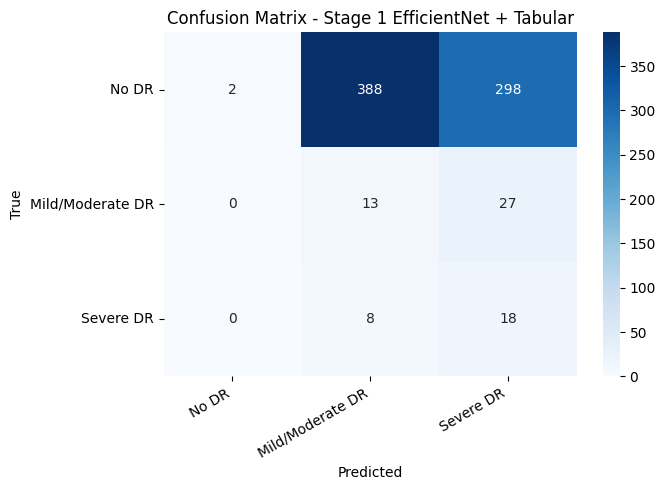

In [16]:
# =========================================================
# 14) EVALUATE STAGE 1 MODEL
# =========================================================

def evaluate_predictions(y_true, y_pred, title, class_names):
    print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro", zero_division=0))
    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Prediction distribution:")
    print(pd.Series(y_pred).value_counts().sort_index())
    print("True distribution:")
    print(pd.Series(y_true).value_counts().sort_index())
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)), target_names=class_names, zero_division=0))


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

stage1_val_prob = stage1_model.predict(val_ds, verbose=1)
stage1_val_pred = np.argmax(stage1_val_prob, axis=1)

stage1_test_prob = stage1_model.predict(test_ds, verbose=1)
stage1_test_pred = np.argmax(stage1_test_prob, axis=1)

stage1_val_macro_f1 = f1_score(y_val, stage1_val_pred, average="macro", zero_division=0)
stage1_val_acc = accuracy_score(y_val, stage1_val_pred)

evaluate_predictions(y_test, stage1_test_pred, "Stage 1 Test Evaluation", CLASS_NAMES)
plot_confusion(y_test, stage1_test_pred, "Confusion Matrix - Stage 1 EfficientNet + Tabular")

## **Stage 2: Extract Fine-tuned Embeddings and Build Patient Graph**

In [17]:
# =========================================================
# 15) BUILD GRAPH DATAFRAME FROM ORIGINAL PATIENTS
# =========================================================

train_graph_df = train_df.copy()
val_graph_df = val_df.copy()
test_graph_df = test_df.copy()

train_graph_df["split"] = "train"
val_graph_df["split"] = "val"
test_graph_df["split"] = "test"

graph_df = pd.concat([train_graph_df, val_graph_df, test_graph_df], axis=0).reset_index(drop=True)
graph_df[TARGET] = graph_df[TARGET].astype(int)

y_all_np = graph_df[TARGET].values.astype("int32")
train_mask_np = (graph_df["split"] == "train").values.astype("float32")
val_mask_np = (graph_df["split"] == "val").values.astype("float32")
test_mask_np = (graph_df["split"] == "test").values.astype("float32")

train_indices = np.where(train_mask_np == 1)[0]
val_indices = np.where(val_mask_np == 1)[0]
test_indices = np.where(test_mask_np == 1)[0]

print("graph_df shape:", graph_df.shape)
print(graph_df["split"].value_counts())
print("Target distribution by split:")
print(pd.crosstab(graph_df["split"], graph_df[TARGET]))

graph_df shape: (7612, 14)
split
train    6094
val       764
test      754
Name: count, dtype: int64
Target distribution by split:
target     0    1    2
split                 
test     688   40   26
train   5658  230  206
val      719   29   16


In [18]:
# =========================================================
# 16) TABULAR FEATURES FOR GRAPH NODES
# =========================================================

X_graph_tab_raw = prepare_tabular_df(graph_df, tabular_features)
train_rows = graph_df["split"] == "train"

graph_tab_imputer = SimpleImputer(strategy="median")
graph_tab_scaler = StandardScaler()

X_graph_tab_train = graph_tab_imputer.fit_transform(X_graph_tab_raw.loc[train_rows])
X_graph_tab_train = graph_tab_scaler.fit_transform(X_graph_tab_train)

X_graph_tab_all = graph_tab_imputer.transform(X_graph_tab_raw)
X_graph_tab_all = graph_tab_scaler.transform(X_graph_tab_all).astype("float32")

print("X_graph_tab_all:", X_graph_tab_all.shape)

X_graph_tab_all: (7612, 9)


In [19]:
# =========================================================
# 17) EXTRACT TRAINED LEFT/RIGHT IMAGE EMBEDDINGS
# =========================================================

def make_image_only_dataset(paths, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda p: load_image(p), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

left_ds_emb = make_image_only_dataset(graph_df["left_image_path"].values, batch_size=EMB_BATCH_SIZE)
right_ds_emb = make_image_only_dataset(graph_df["right_image_path"].values, batch_size=EMB_BATCH_SIZE)

left_img_emb = image_encoder.predict(left_ds_emb, verbose=1).astype("float32")
right_img_emb = image_encoder.predict(right_ds_emb, verbose=1).astype("float32")

print("left_img_emb :", left_img_emb.shape)
print("right_img_emb:", right_img_emb.shape)

476/476 [==============================] - 20s 41ms/step
left_img_emb : (7612, 256)
right_img_emb: (7612, 256)


In [20]:
# =========================================================
# 18) FINAL NODE FEATURE MATRIX
# =========================================================

X_nodes_np = np.concatenate([left_img_emb, right_img_emb, X_graph_tab_all], axis=1).astype("float32")

print("X_nodes_np:", X_nodes_np.shape)
print("y_all_np  :", y_all_np.shape)

X_nodes_np: (7612, 521)
y_all_np  : (7612,)


In [21]:
# =========================================================
# 19) BUILD PATIENT SIMILARITY GRAPH
# =========================================================

graph_feature_scaler = StandardScaler()
X_graph_features_train = graph_feature_scaler.fit_transform(X_nodes_np[train_indices])
X_graph_features_all = graph_feature_scaler.transform(X_nodes_np).astype("float32")

n_components = min(PCA_COMPONENTS_FOR_GRAPH, X_graph_features_all.shape[1], len(train_indices) - 1)
print("PCA components used for graph:", n_components)

pca_graph = PCA(n_components=n_components, random_state=SEED)
pca_graph.fit(X_graph_features_train)
X_edge_all = pca_graph.transform(X_graph_features_all).astype("float32")

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="euclidean")
nbrs.fit(X_edge_all)
distances, indices = nbrs.kneighbors(X_edge_all)

edge_src = []
edge_dst = []
num_nodes = len(graph_df)

for i in range(num_nodes):
    for j in indices[i]:
        if i == j:
            continue
        edge_src.append(i)
        edge_dst.append(j)
        edge_src.append(j)
        edge_dst.append(i)

for i in range(num_nodes):
    edge_src.append(i)
    edge_dst.append(i)

edge_pairs = pd.DataFrame({"src": edge_src, "dst": edge_dst}).drop_duplicates()
edge_index_np = edge_pairs[["src", "dst"]].values.T.astype("int32")

print("Number of nodes:", num_nodes)
print("edge_index shape:", edge_index_np.shape)
print("Number of edges:", edge_index_np.shape[1])

PCA components used for graph: 64
Number of nodes: 7612
edge_index shape: (2, 71384)
Number of edges: 71384


In [22]:
# =========================================================
# 20) CONVERT GRAPH DATA TO TENSORS
# =========================================================

X_nodes = tf.constant(X_nodes_np, dtype=tf.float32)
edge_index = tf.constant(edge_index_np, dtype=tf.int32)
y_all = tf.constant(y_all_np, dtype=tf.int32)

train_mask = tf.constant(train_mask_np, dtype=tf.float32)
val_mask = tf.constant(val_mask_np, dtype=tf.float32)
test_mask = tf.constant(test_mask_np, dtype=tf.float32)

print("X_nodes:", X_nodes.shape)
print("edge_index:", edge_index.shape)
print("Train nodes:", len(train_indices))
print("Val nodes:", len(val_indices))
print("Test nodes:", len(test_indices))

X_nodes: (7612, 521)
edge_index: (2, 71384)
Train nodes: 6094
Val nodes: 764
Test nodes: 754


## **Stage 3: Patient Similarity GAT**

In [23]:
# =========================================================
# 21) CUSTOM GRAPH ATTENTION LAYERS
# =========================================================

class GraphAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, out_dim, dropout_rate=0.2, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.dropout_rate = dropout_rate
        self.alpha = alpha
        self.leaky_relu = tf.keras.layers.LeakyReLU(alpha=alpha)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def build(self, input_shape):
        feature_dim = int(input_shape[0][-1])
        self.W = self.add_weight(shape=(feature_dim, self.out_dim), initializer="glorot_uniform", trainable=True, name="W")
        self.a_src = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_src")
        self.a_dst = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_dst")

    def call(self, inputs, training=False, return_attention=False):
        X, edge_index = inputs
        src = edge_index[0]
        dst = edge_index[1]

        H = tf.matmul(X, self.W)
        H_src = tf.gather(H, src)
        H_dst = tf.gather(H, dst)

        e = self.leaky_relu(tf.matmul(H_src, self.a_src) + tf.matmul(H_dst, self.a_dst))
        e = tf.squeeze(e, axis=-1)

        num_nodes = tf.shape(X)[0]
        max_per_dst = tf.math.unsorted_segment_max(e, dst, num_segments=num_nodes)
        e_exp = tf.exp(e - tf.gather(max_per_dst, dst))
        denom = tf.math.unsorted_segment_sum(e_exp, dst, num_segments=num_nodes)
        attention = e_exp / (tf.gather(denom, dst) + 1e-9)
        attention = self.dropout(attention, training=training)

        messages = H_src * tf.expand_dims(attention, axis=-1)
        out = tf.math.unsorted_segment_sum(messages, dst, num_segments=num_nodes)

        if return_attention:
            return out, attention
        return out


class MultiHeadGAT(tf.keras.layers.Layer):
    def __init__(self, out_dim, num_heads=4, concat=True, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.heads = [
            GraphAttentionLayer(out_dim=out_dim, dropout_rate=dropout_rate, name=f"gat_head_{i}")
            for i in range(num_heads)
        ]
        self.concat = concat

    def call(self, inputs, training=False):
        outputs = [head(inputs, training=training) for head in self.heads]
        if self.concat:
            return tf.concat(outputs, axis=-1)
        return tf.reduce_mean(tf.stack(outputs, axis=0), axis=0)

In [27]:
# =========================================================
# 22) PATIENT SIMILARITY GAT MODEL
# =========================================================

class PatientGATModel(tf.keras.Model):
    def __init__(self, hidden_dim=48, num_heads=3, num_classes=3, dropout_rate=0.25):
        super().__init__()
        self.input_dense = tf.keras.layers.Dense(96, activation="relu")
        self.input_dropout = tf.keras.layers.Dropout(dropout_rate)

        self.gat1 = MultiHeadGAT(out_dim=hidden_dim, num_heads=num_heads, concat=True, dropout_rate=dropout_rate)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)

        self.gat2 = GraphAttentionLayer(out_dim=hidden_dim, dropout_rate=dropout_rate, name="gat_2")
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax", name="target_classifier")

    def call(self, inputs, training=False):
        X, edge_index = inputs
        x = self.input_dense(X)
        x = self.input_dropout(x, training=training)

        x = self.gat1([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn1(x, training=training)
        x = self.dropout1(x, training=training)

        x = self.gat2([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn2(x, training=training)
        x = self.dropout2(x, training=training)

        return self.classifier(x)


gat_model = PatientGATModel(hidden_dim=48, num_heads=3, num_classes=NUM_CLASSES, dropout_rate=0.25)
dummy_output = gat_model([X_nodes, edge_index], training=False)
print("GAT output shape:", dummy_output.shape)

GAT output shape: (7612, 3)


In [28]:
# =========================================================
# GAT LOSS - SEVERE DR RECALL FOCUSED
# =========================================================

def sparse_categorical_focal_loss_per_sample(y_true, y_pred, gamma=1.0):
    y_true = tf.cast(y_true, tf.int32)
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    ce = -y_true_one_hot * tf.math.log(y_pred)
    focal_factor = tf.pow(1.0 - y_pred, gamma)

    loss = focal_factor * ce

    return tf.reduce_sum(loss, axis=-1)


# 3-class:
# 0 = No DR
# 1 = Mild/Moderate DR
# 2 = Severe DR
graph_class_weights = {
    0: 1.0,
    1: 1.8,
    2: 5.0     # Strong boost for Severe DR recall
}

class_weight_vector = tf.constant(
    [graph_class_weights[i] for i in range(NUM_CLASSES)],
    dtype=tf.float32
)

print("Severe-focused graph class weights:", graph_class_weights)


def masked_weighted_focal_loss(y_true, y_pred, mask):
    per_sample_loss = sparse_categorical_focal_loss_per_sample(
        y_true,
        y_pred,
        gamma=1.0
    )

    label_weights = tf.gather(class_weight_vector, y_true)

    weighted_loss = per_sample_loss * label_weights * mask

    return tf.reduce_sum(weighted_loss) / (tf.reduce_sum(mask) + 1e-9)


def masked_accuracy(y_true, y_pred, mask):
    preds = tf.argmax(y_pred, axis=1, output_type=tf.int32)
    correct = tf.cast(tf.equal(preds, y_true), tf.float32)
    correct = correct * mask

    return tf.reduce_sum(correct) / (tf.reduce_sum(mask) + 1e-9)

Severe-focused graph class weights: {0: 1.0, 1: 1.8, 2: 5.0}


In [29]:
# =========================================================
# 24) TRAIN GAT WITH MACRO F1 MONITORING
# =========================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
EPOCHS = 150
PATIENCE = 30
MIN_DELTA = 1e-4

best_val_metric = -np.inf
best_weights = None
wait = 0

history_gat = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_macro_f1": []
}


def get_split_metrics(y_true_np, y_pred_np, indices):
    y_t = y_true_np[indices]
    y_p = y_pred_np[indices]
    acc = np.mean(y_t == y_p)
    bal_acc = balanced_accuracy_score(y_t, y_p)
    macro_f1 = f1_score(y_t, y_p, average="macro", zero_division=0)
    pred_dist = pd.Series(y_p).value_counts().sort_index().to_dict()
    return acc, bal_acc, macro_f1, pred_dist

print("Training nodes:", len(train_indices))
print("Validation nodes:", len(val_indices))
print("Training started...")

for epoch in range(1, EPOCHS + 1):
    with tf.GradientTape() as tape:
        y_pred_all_train = gat_model([X_nodes, edge_index], training=True)
        train_loss = masked_weighted_focal_loss(y_all, y_pred_all_train, train_mask)

    grads = tape.gradient(train_loss, gat_model.trainable_variables)
    grads_and_vars = [(g, v) for g, v in zip(grads, gat_model.trainable_variables) if g is not None]

    if len(grads_and_vars) == 0:
        raise ValueError("No gradients found. Model is not training.")

    optimizer.apply_gradients(grads_and_vars)

    y_pred_all_eval = gat_model([X_nodes, edge_index], training=False)
    val_loss = masked_weighted_focal_loss(y_all, y_pred_all_eval, val_mask)
    train_acc_tf = masked_accuracy(y_all, y_pred_all_eval, train_mask)
    val_acc_tf = masked_accuracy(y_all, y_pred_all_eval, val_mask)

    y_prob_np = y_pred_all_eval.numpy()
    y_pred_np = np.argmax(y_prob_np, axis=1)

    train_acc, train_bal_acc, train_macro_f1, train_pred_dist = get_split_metrics(y_all_np, y_pred_np, train_indices)
    val_acc, val_bal_acc, val_macro_f1, val_pred_dist = get_split_metrics(y_all_np, y_pred_np, val_indices)

    history_gat["train_loss"].append(float(train_loss))
    history_gat["val_loss"].append(float(val_loss))
    history_gat["train_acc"].append(float(train_acc_tf))
    history_gat["val_acc"].append(float(val_acc_tf))
    history_gat["val_bal_acc"].append(float(val_bal_acc))
    history_gat["val_macro_f1"].append(float(val_macro_f1))

    current_metric = val_macro_f1
    if current_metric > best_val_metric + MIN_DELTA:
        best_val_metric = current_metric
        best_weights = copy.deepcopy(gat_model.get_weights())
        wait = 0
        improved = "*"
    else:
        wait += 1
        improved = ""

    print(
        f"Epoch {epoch:03d} {improved} | "
        f"Train Loss: {float(train_loss):.4f} | "
        f"Val Loss: {float(val_loss):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val BalAcc: {val_bal_acc:.4f} | "
        f"Val MacroF1: {val_macro_f1:.4f} | "
        f"Val Pred Dist: {val_pred_dist}"
    )

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_weights is not None:
    gat_model.set_weights(best_weights)
    print("Restored best GAT weights.")
    print("Best validation Macro F1:", best_val_metric)
else:
    print("No best GAT weights saved.")

Training nodes: 6094
Validation nodes: 764
Training started...


2026-05-12 21:27:46.419774: I external/local_xla/xla/service/service.cc:168] XLA service 0x57f6aa40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-12 21:27:46.419839: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-05-12 21:27:46.444621: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778610466.599939   28321 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 001 * | Train Loss: 2.2068 | Val Loss: 0.5838 | Train Acc: 0.7975 | Val Acc: 0.8102 | Val BalAcc: 0.3201 | Val MacroF1: 0.3132 | Val Pred Dist: {0: 657, 1: 107}
Epoch 002 * | Train Loss: 2.1625 | Val Loss: 0.5820 | Train Acc: 0.7985 | Val Acc: 0.8115 | Val BalAcc: 0.3205 | Val MacroF1: 0.3135 | Val Pred Dist: {0: 658, 1: 106}
Epoch 003 * | Train Loss: 2.1238 | Val Loss: 0.5796 | Train Acc: 0.7996 | Val Acc: 0.8128 | Val BalAcc: 0.3210 | Val MacroF1: 0.3139 | Val Pred Dist: {0: 659, 1: 105}
Epoch 004  | Train Loss: 2.0438 | Val Loss: 0.5773 | Train Acc: 0.8014 | Val Acc: 0.8115 | Val BalAcc: 0.3095 | Val MacroF1: 0.3088 | Val Pred Dist: {0: 660, 1: 104}
Epoch 005  | Train Loss: 2.0273 | Val Loss: 0.5750 | Train Acc: 0.8036 | Val Acc: 0.8128 | Val BalAcc: 0.3100 | Val MacroF1: 0.3091 | Val Pred Dist: {0: 661, 1: 103}
Epoch 006  | Train Loss: 2.0456 | Val Loss: 0.5725 | Train Acc: 0.8062 | Val Acc: 0.8128 | Val BalAcc: 0.3100 | Val MacroF1: 0.3091 | Val Pred Dist: {0: 661, 1: 103}
E

## **Evaluation and Final Model Selection**

Stage 1 validation accuracy: 0.031413612565445025
Stage 1 validation Macro F1: 0.036161153825647004
GAT validation accuracy: 0.9463350785340314
GAT validation Macro F1: 0.668906209826926
Selected final model: GAT

Final Selected Model Test Evaluation: GAT
Accuracy: 0.9098143236074271
Balanced Accuracy: 0.5308512224209899
Macro F1: 0.5579121670266378
Weighted F1: 0.9048948444867114
Prediction distribution:
0    701
1     35
2     18
Name: count, dtype: int64
True distribution:
0    688
1     40
2     26
Name: count, dtype: int64
Classification Report:
                  precision    recall  f1-score   support

           No DR       0.95      0.97      0.96       688
Mild/Moderate DR       0.23      0.20      0.21        40
       Severe DR       0.61      0.42      0.50        26

        accuracy                           0.91       754
       macro avg       0.60      0.53      0.56       754
    weighted avg       0.90      0.91      0.90       754



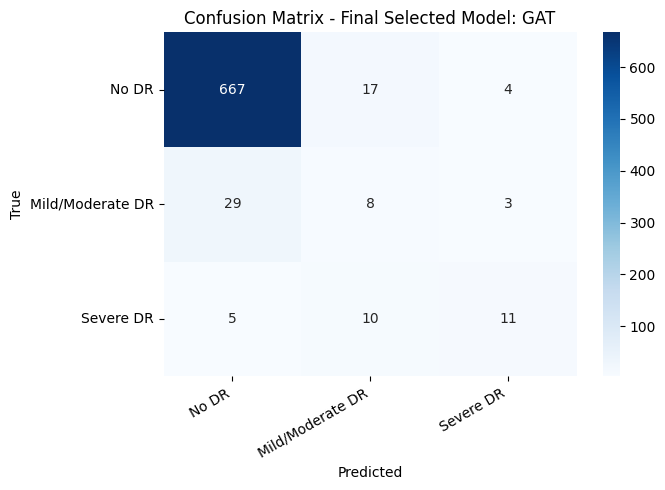

In [30]:
# =========================================================
# 25) FINAL EVALUATION: STAGE 1 VS GAT
# =========================================================

# Stage 1 metrics already computed earlier.
print("Stage 1 validation accuracy:", stage1_val_acc)
print("Stage 1 validation Macro F1:", stage1_val_macro_f1)

# GAT validation and test predictions.
y_prob_all = gat_model([X_nodes, edge_index], training=False).numpy()
y_pred_all = np.argmax(y_prob_all, axis=1)

gat_val_pred = y_pred_all[val_indices]
gat_test_pred = y_pred_all[test_indices]

gat_val_macro_f1 = f1_score(y_all_np[val_indices], gat_val_pred, average="macro", zero_division=0)
gat_val_acc = accuracy_score(y_all_np[val_indices], gat_val_pred)

print("GAT validation accuracy:", gat_val_acc)
print("GAT validation Macro F1:", gat_val_macro_f1)

if gat_val_macro_f1 >= stage1_val_macro_f1:
    FINAL_MODEL_NAME = "GAT"
    final_y_test_pred = gat_test_pred
else:
    FINAL_MODEL_NAME = "Stage 1 EfficientNet + Tabular"
    final_y_test_pred = stage1_test_pred

print("Selected final model:", FINAL_MODEL_NAME)
print()

evaluate_predictions(y_test, final_y_test_pred, f"Final Selected Model Test Evaluation: {FINAL_MODEL_NAME}", CLASS_NAMES)
plot_confusion(y_test, final_y_test_pred, f"Confusion Matrix - Final Selected Model: {FINAL_MODEL_NAME}")

GAT Test Evaluation
Accuracy: 0.8779840848806366
Balanced Accuracy: 0.5921138938580799
Macro F1: 0.5471789482360699
Weighted F1: 0.8893433012722124
Prediction distribution:
0    660
1     56
2     38
Name: count, dtype: int64
True distribution:
0    688
1     40
2     26
Name: count, dtype: int64
Classification Report:
                  precision    recall  f1-score   support

           No DR       0.96      0.92      0.94       688
Mild/Moderate DR       0.20      0.28      0.23        40
       Severe DR       0.39      0.58      0.47        26

        accuracy                           0.88       754
       macro avg       0.52      0.59      0.55       754
    weighted avg       0.90      0.88      0.89       754



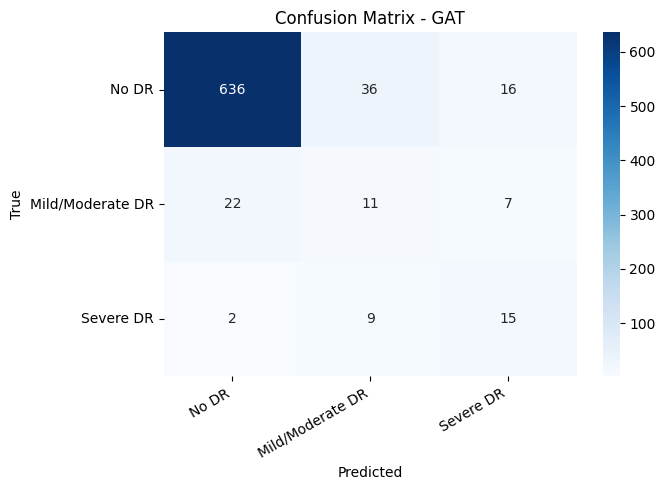

In [41]:
# =========================================================
# 26) DETAILED GAT TEST EVALUATION
# =========================================================

evaluate_predictions(y_all_np[test_indices], gat_test_pred, "GAT Test Evaluation", CLASS_NAMES)
plot_confusion(y_all_np[test_indices], gat_test_pred, "Confusion Matrix - GAT")

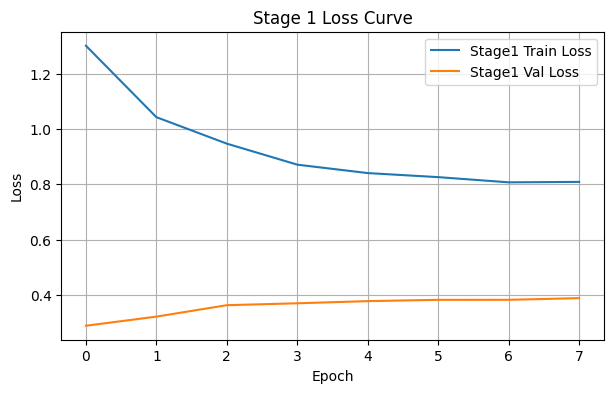

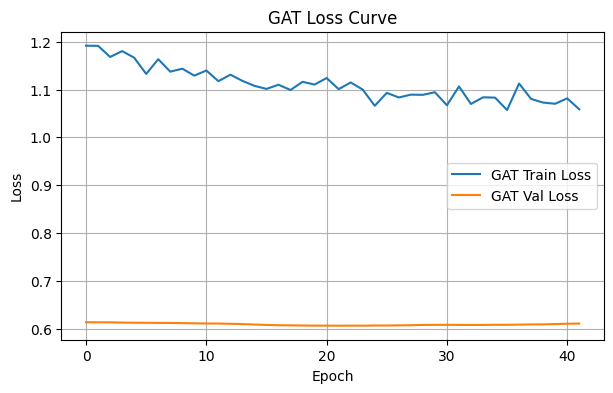

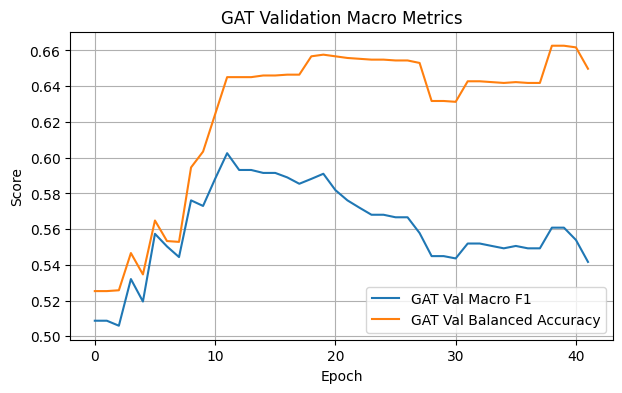

In [42]:
# =========================================================
# 27) TRAINING CURVES
# =========================================================

plt.figure(figsize=(7, 4))
plt.plot(history_stage1.history.get("loss", []), label="Stage1 Train Loss")
plt.plot(history_stage1.history.get("val_loss", []), label="Stage1 Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_gat["train_loss"], label="GAT Train Loss")
plt.plot(history_gat["val_loss"], label="GAT Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAT Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_gat["val_macro_f1"], label="GAT Val Macro F1")
plt.plot(history_gat["val_bal_acc"], label="GAT Val Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("GAT Validation Macro Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# =========================================================
# 28) PREDICTION DISTRIBUTIONS BY SPLIT
# =========================================================

print("GAT train prediction distribution:")
print(pd.Series(y_pred_all[train_indices]).value_counts().sort_index())
print("GAT val prediction distribution:")
print(pd.Series(y_pred_all[val_indices]).value_counts().sort_index())
print("GAT test prediction distribution:")
print(pd.Series(y_pred_all[test_indices]).value_counts().sort_index())

print("True train distribution:")
print(pd.Series(y_all_np[train_indices]).value_counts().sort_index())
print("True val distribution:")
print(pd.Series(y_all_np[val_indices]).value_counts().sort_index())
print("True test distribution:")
print(pd.Series(y_all_np[test_indices]).value_counts().sort_index())

GAT train prediction distribution:
0    5718
1     226
2     150
Name: count, dtype: int64
GAT val prediction distribution:
0    730
1     22
2     12
Name: count, dtype: int64
GAT test prediction distribution:
0    701
1     35
2     18
Name: count, dtype: int64
True train distribution:
0    5658
1     230
2     206
Name: count, dtype: int64
True val distribution:
0    719
1     29
2     16
Name: count, dtype: int64
True test distribution:
0    688
1     40
2     26
Name: count, dtype: int64


In [32]:
# =========================================================
# SEVERE DR RECALL BOOSTING - VALIDATION THRESHOLD SEARCH
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For 3-class setup:
# 0 = No DR
# 1 = Mild/Moderate DR
# 2 = Severe DR
SEVERE_CLASS = 2

# GAT probabilities for all graph nodes
y_prob_all = gat_model(
    [X_nodes, edge_index],
    training=False
).numpy()

y_val_true = y_all_np[val_indices]
y_val_prob = y_prob_all[val_indices]

y_test_true = y_all_np[test_indices]
y_test_prob = y_prob_all[test_indices]


def severe_threshold_predict(y_prob, severe_threshold):
    """
    Normal prediction = argmax.
    But if Severe probability >= threshold, force prediction to Severe.
    """
    y_pred = np.argmax(y_prob, axis=1)

    severe_mask = y_prob[:, SEVERE_CLASS] >= severe_threshold
    y_pred[severe_mask] = SEVERE_CLASS

    return y_pred


thresholds = np.arange(0.05, 0.91, 0.01)

rows = []

for thr in thresholds:
    y_val_pred_thr = severe_threshold_predict(
        y_val_prob,
        severe_threshold=thr
    )

    severe_true_binary = (y_val_true == SEVERE_CLASS).astype(int)
    severe_pred_binary = (y_val_pred_thr == SEVERE_CLASS).astype(int)

    severe_recall = recall_score(
        severe_true_binary,
        severe_pred_binary,
        zero_division=0
    )

    severe_precision = precision_score(
        severe_true_binary,
        severe_pred_binary,
        zero_division=0
    )

    severe_f2 = fbeta_score(
        severe_true_binary,
        severe_pred_binary,
        beta=2,
        zero_division=0
    )

    acc = accuracy_score(y_val_true, y_val_pred_thr)

    bal_acc = balanced_accuracy_score(
        y_val_true,
        y_val_pred_thr
    )

    macro_f1 = f1_score(
        y_val_true,
        y_val_pred_thr,
        average="macro",
        zero_division=0
    )

    pred_dist = pd.Series(y_val_pred_thr).value_counts().sort_index().to_dict()

    rows.append({
        "threshold": thr,
        "val_accuracy": acc,
        "val_balanced_accuracy": bal_acc,
        "val_macro_f1": macro_f1,
        "severe_precision": severe_precision,
        "severe_recall": severe_recall,
        "severe_f2": severe_f2,
        "prediction_distribution": pred_dist
    })

threshold_df = pd.DataFrame(rows)

threshold_df.sort_values(
    by=["severe_recall", "severe_f2", "val_macro_f1"],
    ascending=False
).head(20)

,threshold,val_accuracy,val_balanced_accuracy,val_macro_f1,severe_precision,severe_recall,severe_f2,prediction_distribution
21,0.26,0.816754,0.648298,0.427470,0.109589,1.0,0.380952,"{0: 613, 1: 5, 2: 146}"
20,0.25,0.746073,0.601202,0.358683,0.078818,1.0,0.299625,"{0: 559, 1: 2, 2: 203}"
19,0.24,0.679319,0.566528,0.312734,0.062500,1.0,0.250000,"{0: 507, 1: 1, 2: 256}"
18,0.23,0.585079,0.533148,0.279997,0.048780,1.0,0.204082,"{0: 435, 1: 1, 2: 328}"
17,0.22,0.455497,0.487251,0.234163,0.037296,1.0,0.162272,"{0: 334, 1: 1, 2: 429}"
16,0.21,0.316754,0.438108,0.178591,0.029851,1.0,0.133333,"{0: 227, 1: 1, 2: 536}"
15,0.20,0.200262,0.396847,0.123287,0.025518,1.0,0.115774,"{0: 137, 2: 627}"
14,0.19,0.098168,0.360686,0.065351,0.022695,1.0,0.104031,"{0: 59, 2: 705}"
13,0.18,0.052356,0.344460,0.035644,0.021622,1.0,0.099502,"{0: 24, 2: 740}"
12,0.17,0.027487,0.335651,0.018367,0.021080,1.0,0.097205,"{0: 5, 2: 759}"


In [34]:
# =========================================================
# SELECT BEST THRESHOLD FOR SEVERE DR RECALL
# =========================================================

TARGET_SEVERE_RECALL = 0.60

candidate_df = threshold_df[
    threshold_df["severe_recall"] >= TARGET_SEVERE_RECALL
].copy()

if len(candidate_df) == 0:
    print("No threshold reached target Severe recall.")
    print("Selecting threshold with highest Severe F2 instead.")

    best_row = threshold_df.sort_values(
        by=["severe_f2", "severe_recall", "val_macro_f1"],
        ascending=False
    ).iloc[0]
else:
    print(f"Found thresholds with Severe recall >= {TARGET_SEVERE_RECALL}")

    best_row = candidate_df.sort_values(
        by=["severe_f2", "val_macro_f1", "val_balanced_accuracy"],
        ascending=False
    ).iloc[0]

BEST_SEVERE_THRESHOLD = float(best_row["threshold"])

print("Best Severe threshold:", BEST_SEVERE_THRESHOLD)
print(best_row)

Found thresholds with Severe recall >= 0.6
Best Severe threshold: 0.30000000000000004
threshold                                     0.3
val_accuracy                             0.931937
val_balanced_accuracy                    0.681448
val_macro_f1                             0.584565
severe_precision                         0.368421
severe_recall                               0.875
severe_f2                                0.686275
prediction_distribution    {0: 710, 1: 16, 2: 38}
Name: 25, dtype: object


Thresholded GAT Accuracy: 0.8925729442970822
Thresholded GAT Balanced Accuracy: 0.5952072152653548
Thresholded GAT Macro F1: 0.5304639804639805
Thresholded GAT Weighted F1: 0.8933011727441437

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.96      0.94      0.95       688
Mild/Moderate DR       0.26      0.15      0.19        40
       Severe DR       0.33      0.69      0.45        26

        accuracy                           0.89       754
       macro avg       0.52      0.60      0.53       754
    weighted avg       0.90      0.89      0.89       754


Prediction distribution:
0    677
1     23
2     54
Name: count, dtype: int64

True distribution:
0    688
1     40
2     26
Name: count, dtype: int64


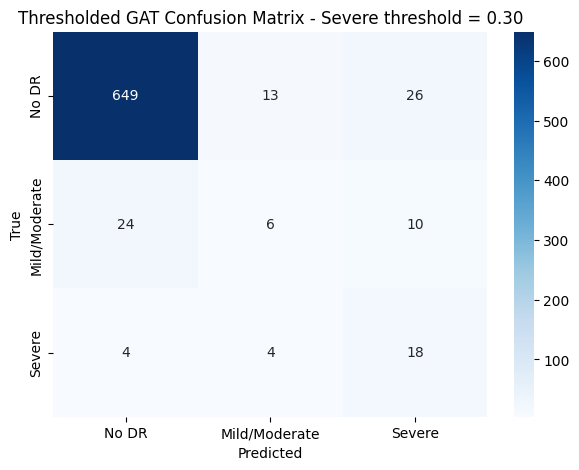

In [35]:
# =========================================================
# TEST EVALUATION AFTER SEVERE-RECALL THRESHOLDING
# =========================================================

y_test_pred_thresholded = severe_threshold_predict(
    y_test_prob,
    severe_threshold=BEST_SEVERE_THRESHOLD
)

print("Thresholded GAT Accuracy:", accuracy_score(y_test_true, y_test_pred_thresholded))
print("Thresholded GAT Balanced Accuracy:", balanced_accuracy_score(y_test_true, y_test_pred_thresholded))
print("Thresholded GAT Macro F1:", f1_score(
    y_test_true,
    y_test_pred_thresholded,
    average="macro",
    zero_division=0
))
print("Thresholded GAT Weighted F1:", f1_score(
    y_test_true,
    y_test_pred_thresholded,
    average="weighted",
    zero_division=0
))

print("\nClassification Report:")
print(classification_report(
    y_test_true,
    y_test_pred_thresholded,
    labels=[0, 1, 2],
    target_names=[
        "No DR",
        "Mild/Moderate DR",
        "Severe DR"
    ],
    zero_division=0
))

print("\nPrediction distribution:")
print(pd.Series(y_test_pred_thresholded).value_counts().sort_index())

print("\nTrue distribution:")
print(pd.Series(y_test_true).value_counts().sort_index())

cm = confusion_matrix(
    y_test_true,
    y_test_pred_thresholded,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No DR", "Mild/Moderate", "Severe"],
    yticklabels=["No DR", "Mild/Moderate", "Severe"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Thresholded GAT Confusion Matrix - Severe threshold = {BEST_SEVERE_THRESHOLD:.2f}")
plt.show()

In [36]:
# =========================================================
# COMPARE ORIGINAL ARGMAX VS SEVERE-THRESHOLDED TEST RESULTS
# =========================================================

y_test_pred_argmax = np.argmax(y_test_prob, axis=1)

def summarize_3class_results(name, y_true, y_pred):
    severe_true_binary = (y_true == SEVERE_CLASS).astype(int)
    severe_pred_binary = (y_pred == SEVERE_CLASS).astype(int)

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "severe_precision": precision_score(severe_true_binary, severe_pred_binary, zero_division=0),
        "severe_recall": recall_score(severe_true_binary, severe_pred_binary, zero_division=0),
        "severe_f2": fbeta_score(severe_true_binary, severe_pred_binary, beta=2, zero_division=0),
        "predicted_severe_count": int(np.sum(y_pred == SEVERE_CLASS))
    }

comparison_results = pd.DataFrame([
    summarize_3class_results(
        "Original Argmax GAT",
        y_test_true,
        y_test_pred_argmax
    ),
    summarize_3class_results(
        f"Thresholded GAT thr={BEST_SEVERE_THRESHOLD:.2f}",
        y_test_true,
        y_test_pred_thresholded
    )
])

comparison_results

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,severe_precision,severe_recall,severe_f2,predicted_severe_count
0,Original Argmax GAT,0.909814,0.530851,0.557912,0.904895,0.611111,0.423077,0.45082,18
1,Thresholded GAT thr=0.30,0.892573,0.595207,0.530464,0.893301,0.333333,0.692308,0.56962,54


## **XAI / Visual Explanation**

In [9]:
# =========================================================
# 29) VISUALIZE ONE RANDOM PATIENT PAIR + CNN FEATURE MAPS
# =========================================================

random_test_idx = np.random.choice(test_indices)
random_patient = graph_df.iloc[random_test_idx]

left_path = random_patient["left_image_path"]
right_path = random_patient["right_image_path"]
true_label = int(random_patient[TARGET])

if FINAL_MODEL_NAME == "GAT":
    pred_label = int(y_pred_all[random_test_idx])
    pred_probs = y_prob_all[random_test_idx]
else:
    local_test_pos = np.where(test_indices == random_test_idx)[0][0]
    pred_label = int(stage1_test_pred[local_test_pos])
    pred_probs = stage1_test_prob[local_test_pos]

print("Random graph index:", random_test_idx)
print("Patient ID:", random_patient["patient_id"])
print("True label:", true_label, CLASS_NAMES[true_label])
print("Predicted label:", pred_label, CLASS_NAMES[pred_label])
print("Predicted probabilities:", np.round(pred_probs, 4))


def load_single_image_np(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()

base_model = None
for layer in image_encoder.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError(f"Could not find EfficientNet layer. Existing layers: {[layer.name for layer in image_encoder.layers]}")

last_spatial_layer_name = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_spatial_layer_name = layer.name
            break
    except Exception:
        continue

if last_spatial_layer_name is None:
    raise ValueError("No 4D spatial layer found inside EfficientNet.")

print("Base CNN model:", base_model.name)
print("Last spatial feature layer:", last_spatial_layer_name)

base_fmap_model = Model(inputs=base_model.input, outputs=base_model.get_layer(last_spatial_layer_name).output)


def get_feature_maps(img_np):
    x = np.expand_dims(img_np, axis=0).astype("float32") * 255.0
    fmap = base_fmap_model.predict(x, verbose=0)[0]
    return fmap


def show_top_feature_maps(img_np, fmap, title, top_k=4):
    channel_scores = fmap.mean(axis=(0, 1))
    top_channels = np.argsort(channel_scores)[-top_k:][::-1]

    plt.figure(figsize=(14, 3))
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

    for idx, ch in enumerate(top_channels):
        activation = fmap[:, :, ch]
        plt.subplot(1, top_k + 1, idx + 2)
        plt.imshow(activation, cmap="gray")
        plt.title(f"Feature {ch}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

left_img_np = load_single_image_np(left_path)
right_img_np = load_single_image_np(right_path)

left_fmap = get_feature_maps(left_img_np)
right_fmap = get_feature_maps(right_img_np)

show_top_feature_maps(left_img_np, left_fmap, "Left Eye - CNN Internal Feature Maps", top_k=4)
show_top_feature_maps(right_img_np, right_fmap, "Right Eye - CNN Internal Feature Maps", top_k=4)

NameError: name 'test_indices' is not defined

In [49]:
# =========================================================
# 30) GAT ATTENTION EXPLANATION FOR SAME RANDOM PATIENT
# =========================================================

x0 = gat_model.input_dense(X_nodes)
x0 = gat_model.gat1([x0, edge_index], training=False)
x0 = tf.nn.elu(x0)
x0 = gat_model.bn1(x0, training=False)

gat2_out, attention_scores = gat_model.gat2([x0, edge_index], training=False, return_attention=True)
attention_scores_np = attention_scores.numpy()
src_np = edge_index_np[0]
dst_np = edge_index_np[1]

incoming_mask = dst_np == random_test_idx
incoming_sources = src_np[incoming_mask]
incoming_attention = attention_scores_np[incoming_mask]

top_order = np.argsort(incoming_attention)[-10:][::-1]

attention_rows = []
for rank, pos in enumerate(top_order, start=1):
    neighbor_idx = incoming_sources[pos]
    att_score = incoming_attention[pos]
    row = graph_df.iloc[neighbor_idx]
    attention_rows.append({
        "rank": rank,
        "neighbor_graph_idx": int(neighbor_idx),
        "neighbor_patient_id": row["patient_id"],
        "split": row["split"],
        "neighbor_label": int(row[TARGET]),
        "neighbor_label_name": CLASS_NAMES[int(row[TARGET])],
        "attention_score": float(att_score)
    })

attention_df = pd.DataFrame(attention_rows)
print("Selected patient:")
print("Graph index:", random_test_idx)
print("Patient ID:", random_patient["patient_id"])
print("True label:", true_label, CLASS_NAMES[true_label])
print("Predicted label:", pred_label, CLASS_NAMES[pred_label])
print("Top GAT attention neighbors:")
display(attention_df)

Selected patient:
Graph index: 7293
Patient ID: 4985
True label: 0 No DR
Predicted label: 0 No DR
Top GAT attention neighbors:


,rank,neighbor_graph_idx,neighbor_patient_id,split,neighbor_label,neighbor_label_name,attention_score
0,1,7293,4985,test,0,No DR,0.187619
1,2,5445,7637,train,0,No DR,0.171139
2,3,4694,6635,train,0,No DR,0.161200
3,4,6276,1946,val,0,No DR,0.160564
4,5,1140,1689,train,0,No DR,0.159854
5,6,3217,4520,train,0,No DR,0.159625


## **Save Artifacts**

In [51]:
# =========================================================
# 31) SAVE MODEL ARTIFACTS
# =========================================================

stage1_model.save("stage1_efficientnet_tabular_3degrees.keras")
gat_model.save_weights("patient_similarity_gat.weights3_3degrees.h5")

np.save("X_nodes_embeddings.npy", X_nodes_np)
np.save("edge_index_patient_graph.npy", edge_index_np)
np.save("y_all_graph.npy", y_all_np)

graph_df.to_csv("graph_patient_dataframe.csv", index=False)

print("Saved artifacts successfully.")

Saved artifacts successfully.
